#### Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from pathlib import Path
from scipy.stats import norm, invgamma, multivariate_normal
import pickle
import os

from scipy import stats as scipy_stats
from scipy.stats import skewnorm, t, nct, norminvgauss
from scipy.optimize import minimize
from skewt_scipy.skewt import skewt

from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import contextlib
import io

from kama_msr import KAMA
from kama_msr import MarkovSwitchingModel
from kama_msr import KAMA_MSR
from kmrf import KMRF
from KMRF_training_config import *
from bayesian_forward_simulator import BayesianForwardSimulator
from portfolio_optimizer_inputs import PortfolioOptimizerInputs
from portfolio_optimizer import PortfolioOptimizer

--- 
## Asset and Fitting Date Choices

#### -------------------------------------------------------------------------------------------------

In [2]:
# Prepare data: etf_close_prices, commodity_close_prices, universe_close_prices
international_index_symbol_names = pd.read_csv('data/inputs/fmp_index_list.csv').set_index('symbol')['name']
international_index_symbol_names = international_index_symbol_names[~international_index_symbol_names.index.isin(['^GSPC', '^NDX'])].to_dict()
commodity_symbol_names = pd.read_csv('data/inputs/fmp_commodity_list.csv').set_index('symbol')['name'].to_dict()
etf_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # International EQUITY ETFS
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
universe_symbol_names = {
    'IVV': 'IVV - iShares Core S&P 500 ETF',
    'IJH': 'IJH - iShares Core S&P Mid-Cap ETF',
    'IWM': 'IWM - iShares Russell 2000 ETF',
    'EFA': 'EFA - iShares MSCI EAFE ETF',
    'EEM': 'EEM - iShares MSCI Emerging Markets ETF',
    'AGG': 'AGG - iShares Core U.S. Aggregate Bond ETF',
    'SPTL': 'SPTL - SPDR Portfolio Long Term Treasury ETF',
    'HYG': 'HYG - iShares iBoxx $ High Yield Corporate Bond ETF',
    'SPBO': 'SPBO - SPDR Portfolio Corporate Bond ETF',
    'IYR': 'IYR - iShares U.S. Real Estate ETF',
    'DBC': 'DBC - Invesco DB Commodity Index Tracking Fund',
    'GLD': 'GLD - SPDR Gold Shares',
}

# international_index_data = pd.read_csv('data/processed/index_data.csv', index_col=0, header=[0, 1], parse_dates=True)
commodity_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
etf_data = pd.read_csv('data/processed/all_etf_data.csv', index_col=0, header=[0, 1], parse_dates=True)
universe_data = pd.read_csv('data/processed/universe_etfs.csv', index_col=0, header=[0, 1], parse_dates=True)

commodity_data_close_cols = commodity_data.columns[commodity_data.columns.get_level_values(1) == 'close']
commodity_close_prices = commodity_data[commodity_data_close_cols].droplevel(1, axis=1).rename(columns=commodity_symbol_names)
commodity_close_prices.columns = [col.replace('/', ' ') for col in commodity_close_prices.columns]

etf_close_cols = etf_data.columns[etf_data.columns.get_level_values(1) == 'close']
etf_close_prices = etf_data[etf_close_cols].droplevel(1, axis=1).rename(columns=etf_symbol_names)

universe_close_cols = universe_data.columns[universe_data.columns.get_level_values(1) == 'close']
universe_close_prices = universe_data[universe_close_cols].droplevel(1, axis=1).rename(columns=universe_symbol_names)

# print('Commodities:', commodity_close_prices.columns.tolist())
# print('ETFs:', etf_close_prices.columns.tolist())
# print('Universe:', universe_close_prices.columns.tolist())

In [3]:
etf_always_disclude = ['Vanguard S&P 500 ETF', 'Real Estate Select Sector SPDR', 'Communication Services Select Sector SPDR']
etf_disclude = [name for name in etf_data.columns if 'Russell 1000' in name or 'Russell 3000' in name]\
                        + ['S&P 500', 'Nasdaq Composite', 'Dow Jones Industrial Average', 'Nasdaq 100', 'Russell 2000']

etf_include = list(set(etf_close_prices.columns.tolist()) - set(etf_always_disclude) - set(etf_disclude))
etf_close_prices = etf_close_prices[etf_include]

us_treasury = ['SPDR Bloomberg 1-3 Month T-Bill ETF', 'iShares 1-3 Year Treasury Bond ETF', 'iShares 7-10 Year Treasury Bond ETF']
int_equity = ['Vanguard Total International Stock ETF', 'Vanguard FTSE Developed Markets ETF',\
                                        'Vanguard FTSE Emerging Markets ETF','Vanguard FTSE Europe ETF',\
                                        'Vanguard FTSE Pacific ETF', 'iShares China Large-Cap ETF',\
                                        'iShares MSCI Japan ETF', 'iShares MSCI India ETF']
us_equity = list(set(etf_include) - set(us_treasury) - set(int_equity))

#### -------------------------------------------------------------------------------------------------

In [4]:
# Create asset_names_df
from KMRF_training_config import *
asset_names_df = pd.DataFrame({
    'universe': get_assets_by_class('universe') + ['']*7,
    'us_equity': get_assets_by_class('us_equity'),
    'commodity': get_assets_by_class('commodity') + ['']*5,
    'int_equity': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,universe,us_equity,commodity,int_equity
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


In [5]:
rebal_dates = etf_close_prices['SPDR S&P 500 ETF'].to_frame().dropna().loc['2018-12-31':].index[::21].map(lambda dte: dte.strftime('%Y%m%d')).to_list()
rebal_dates[:12]

['20181231',
 '20190131',
 '20190304',
 '20190402',
 '20190502',
 '20190603',
 '20190702',
 '20190801',
 '20190830',
 '20191001',
 '20191030',
 '20191129']

In [6]:
def load_models(asset_class: str, asset_name: str, end_date: str = '20181231') -> Tuple[KAMA_MSR, KMRF]:
    def _get_kama_msr_path(asset_class:str, asset_name: str, end_date: str) -> Path:
        filename = f"{asset_name}_KAMA-MSR_4-regimes.pkl"
        return Path('saved_models') / 'KAMA_MSR' / asset_class / end_date / filename

    def _get_kmrf_path(asset_class:str, asset_name: str) -> Path:
        filename = f"{asset_name}_KMRF_model.pkl"
        return Path('saved_models') / 'KMRF_new' / 'original' / asset_class / filename

    kama_msr_path = _get_kama_msr_path(asset_class, asset_name, end_date)
    kmrf_path = _get_kmrf_path(asset_class, asset_name)
    
    # Check if files exist
    if not kama_msr_path.exists():
        raise FileNotFoundError(
            f"KAMA+MSR model not found for {asset_name}: {kama_msr_path}"
        )
    if not kmrf_path.exists():
        raise FileNotFoundError(
            f"KMRF model not found for {asset_name}: {kmrf_path}"
        )
    
    # Load KAMA+MSR
    with open(kama_msr_path, 'rb') as f:
        kama_msr = pickle.load(f)
    
    # Load KMRF (suppress output)
    with contextlib.redirect_stdout(io.StringIO()):
        kmrf = KMRF.load_model(str(kmrf_path))
    
    return kama_msr, kmrf


#### -------------------------------------------------------------------------------------------------

In [7]:
# rebal_dates[-12:]

In [8]:
DATE = rebal_dates[-12]
ASSET_CLASS = 'us_equity' # only used for BayesianForwardSimulator part
ASSET_NAME = 'SPDR S&P 500 ETF'
print(pd.Timestamp(DATE))

2024-11-01 00:00:00


---

## Using the BayesianForwardSimulator Class


In [9]:
kama_msr, kmrf = PortfolioOptimizerInputs(asset_names=[ASSET_NAME], asset_class=ASSET_CLASS, end_date=DATE,
                                     retrain_kmrf=True)\
                                     .load_models(ASSET_NAME, kmrf=True)


KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  Training end date: 20241101
  Test end date: All available data
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20241101
  Validation/Test split: Will be calculated after loading data
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=False, Consensus=False



BAYESIAN FORWARD SIMULATION - FULL ANALYSIS

[1/5] Computing forward regime probabilities...
✓ Computed 21-day forward probabilities

[2/5] Fitting regime-specific distributions...

FITTING DISTRIBUTIONS BY REGIME (WITH SIGNIFICANCE TESTING)

Regime 0:
  N=5629, μ=0.00052, σ=0.00840
  skew=-0.371 (p=0.0000)***
  kurt=1.421 (p=0.0000)***
  → Normal Inverse Gaussian (both skew and kurt significant)
     MLE converged: a=1.3252, b=-0.1854, loc=0.00188, scale=0.00960

Regime 1:
  N=1366, μ=0.00070, σ=0.01236
  skew=-0.020 (p=0.7675)
  kurt=-0.019 (p=0.8863)
  → Normal distribution

Regime 2:
  N=65, μ=-0.01140, σ=0.02914
  skew=0.276 (p=0.2475)
  kurt=0.029 (p=0.9475)
  → Normal distribution

Regime 3:
  N=433, μ=-0.00152, σ=0.03107
  skew=0.077 (p=0.5145)
  kurt=1.409 (p=0.0000)***
  → Student-t: df=8.26


[3/5] Validating distribution parameters...

DISTRIBUTION PARAMETER VALIDATION
 regime distribution  valid       loc    scale       df       a        b  n_obs
      0 norminvgauss   Tr

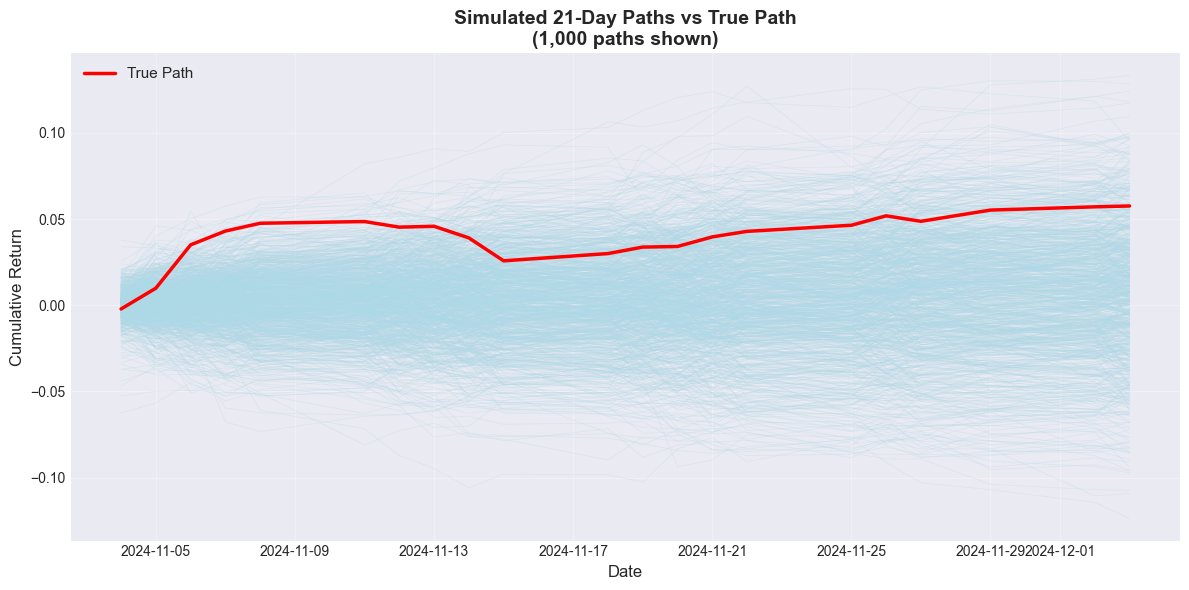

Generating terminal distribution...


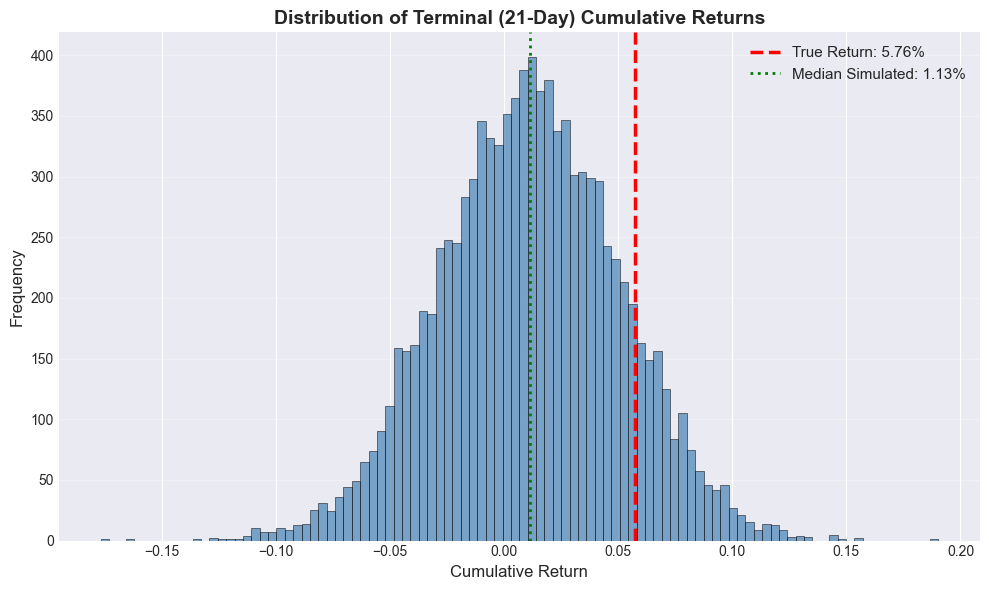


ANALYSIS COMPLETE


In [13]:
# Create simulator instance
simulator = BayesianForwardSimulator(
    kama_msr=kama_msr,
    kmrf=kmrf,
    n_days=21,
    alpha_confidence=0.75,
    significance_level=0.05
)

# Run full analysis pipeline
sim_results = simulator.run_full_analysis(
    n_simulations=10000,
    random_seed=1010,
    plot_paths=True,
    plot_terminal=True,
    n_paths_to_plot=1000
)

In [14]:
print(sim_results.keys())
sim_results['summary_stats']

dict_keys(['forward_probs', 'regime_distributions', 'validation', 'simulated_returns', 'summary_stats'])


count                 10000.000000
mean                      0.011180
std                       0.039548
min                      -0.176712
25%                      -0.015268
50%                       0.011323
75%                       0.037919
max                       0.190207
true_return               0.057562
percentile_of_true       87.930000
Name: Day t+21, dtype: float64

---

## Portfolio Optimization Inputs Generator

The `PortfolioOptimizerInputs` class generates μ and Σ for multiple assets using regime-conditional Bayesian simulations.

#### Example: Quick Run for Portfolio

In [8]:
# asset_names_df[ASSET_CLASS]

In [9]:
ANNUALIZE = True
portfolio_assets = asset_names_df[ASSET_CLASS][4:15].to_list()
results = PortfolioOptimizerInputs.quick_run(
    asset_names=portfolio_assets,
    asset_class=ASSET_CLASS,
    end_date=DATE,
    n_days=21,
    n_simulations=10000,
    method='path_covariance',
    annualize=ANNUALIZE,
    verbose=True,
    random_seed=1010,
    retrain_kmrf=True,
    use_boruta_selection=False,
    use_consensus_selection=False
)


PORTFOLIO SIMULATION: 11 ASSETS
Asset Class: us_equity
End Date: 20241101
Horizon: 21 days
Simulations per asset: 10,000

[1/11] Processing Energy Select Sector SPDR...

SIMULATING: Energy Select Sector SPDR
Loading models...
KMRF model initialized
  Asset: Energy Select Sector SPDR
  Asset class: us_equity
  Classification type: original
  Training end date: 20241101
  Test end date: All available data
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20241101
  Validation/Test split: Will be calculated after loading data
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=False, Consensus=False
Computing forward probabilities...
Fitting regime distributions...

FITTING DISTRIBUTIONS BY REGIME (WITH SIGNIFICANCE TESTING)

Regime 0:


In [11]:
if not ANNUALIZE:
    # Extract 21-day values
    mu_21day = results['inputs']['mu']
    sigma_21day = results['inputs']['volatility']

    # Compute daily values (divide by n_days for returns, sqrt(n_days) for volatility)
    mu_daily = mu_21day / 21
    sigma_daily = sigma_21day / np.sqrt(21)

    # Compute annualized values (multiply by scaling factor)
    annualization_factor = 252 / 21
    mu_annual = mu_21day * annualization_factor
    sigma_annual = sigma_21day * np.sqrt(annualization_factor)

    # Create comparison DataFrame
    comparison = pd.DataFrame({
        'Daily Return': mu_daily,
        'Daily Volatility': sigma_daily,
        '21-Day Return': mu_21day,
        '21-Day Volatility': sigma_21day,
        'Annual Return': mu_annual,
        'Annual Volatility': sigma_annual
    })

    print("\n")
    display(comparison)

    print("\n" + "="*80)
    print(f"Scaling Factors:")
    print(f"  Daily → 21-Day: multiply by {21}")
    print(f"  Daily → Annual: multiply by {252}")
    print(f"  21-Day → Annual: multiply by {252/21:.2f}")
    print(f"  Volatility scales by sqrt(time)")
    print("="*80)

In [12]:
print(results.keys())
print(results['inputs'].keys())

display(results['inputs']['mu'])
display(results['inputs']['Sigma'])

dict_keys(['inputs', 'instance', 'summary', 'asset_simulations'])
dict_keys(['mu', 'Sigma', 'correlation', 'volatility'])


Energy Select Sector SPDR                    0.127257
Financial Select Sector SPDR                 0.076986
Utilities Select Sector SPDR                 0.036242
Industrial Select Sector SPDR                0.092395
Health Care Select Sector SPDR               0.038779
Technology Select Sector SPDR                0.166500
Materials Select Sector SPDR                 0.057728
Consumer Discretionary Select Sector SPDR    0.137261
Consumer Staples Select Sector SPDR          0.050586
iShares S&P 500 Growth ETF                   0.136466
iShares S&P 500 Value ETF                    0.082313
dtype: float64

,Energy Select Sector SPDR,Financial Select Sector SPDR,Utilities Select Sector SPDR,Industrial Select Sector SPDR,Health Care Select Sector SPDR,Technology Select Sector SPDR,Materials Select Sector SPDR,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,iShares S&P 500 Growth ETF,iShares S&P 500 Value ETF
Energy Select Sector SPDR,0.054776,0.000127,0.000079,0.000018,0.000054,0.000337,0.000073,0.000157,-0.000030,0.000038,0.000124
Financial Select Sector SPDR,0.000127,0.027618,0.000820,0.000099,0.000640,0.000308,0.000098,0.000134,0.000038,0.000018,0.000103
Utilities Select Sector SPDR,0.000079,0.000820,0.020554,0.000313,0.000103,0.000043,-0.000016,0.000221,0.000043,0.000004,0.000093
Industrial Select Sector SPDR,0.000018,0.000099,0.000313,0.023435,0.000117,0.000154,0.000052,0.000241,-0.000059,-0.000027,0.000807
Health Care Select Sector SPDR,0.000054,0.000640,0.000103,0.000117,0.019703,0.000177,0.000049,0.000079,-0.000015,0.000081,0.000091
Technology Select Sector SPDR,0.000337,0.000308,0.000043,0.000154,0.000177,0.030004,-0.000008,0.000182,0.000028,0.000094,0.000087
Materials Select Sector SPDR,0.000073,0.000098,-0.000016,0.000052,0.000049,-0.000008,0.032593,0.000100,-0.000046,0.000363,0.000005
Consumer Discretionary Select Sector SPDR,0.000157,0.000134,0.000221,0.000241,0.000079,0.000182,0.000100,0.023677,0.000034,-0.000012,0.000848
Consumer Staples Select Sector SPDR,-0.000030,0.000038,0.000043,-0.000059,-0.000015,0.000028,-0.000046,0.000034,0.013893,0.000056,-0.000025
iShares S&P 500 Growth ETF,0.000038,0.000018,0.000004,-0.000027,0.000081,0.000094,0.000363,-0.000012,0.000056,0.018461,-0.000004


#### Save Results for Later Use

In [22]:
# results['instance'].save_results(output_path = 'simulations', filename='test1_20181231.pkl')
with open(f'simulations/test1_{DATE}.pkl', 'wb') as f:
    pickle.dump(results, f)


---
## Portfolio Optimization

In [9]:
results = pickle.load(open(f'simulations/test1_{DATE}.pkl', 'rb'))
print(results.keys())

dict_keys(['inputs', 'instance', 'summary', 'asset_simulations'])


In [10]:
opt = PortfolioOptimizer.from_optimizer_inputs(results, allow_short=True, gross_exposure=1.5, 
                                               objective='max_sharpe')
opt.optimize()

Energy Select Sector SPDR                    0.056674
Financial Select Sector SPDR                 0.064556
Utilities Select Sector SPDR                 0.037570
Industrial Select Sector SPDR                0.092497
Health Care Select Sector SPDR               0.043540
Technology Select Sector SPDR                0.136006
Materials Select Sector SPDR                 0.041803
Consumer Discretionary Select Sector SPDR    0.138667
Consumer Staples Select Sector SPDR          0.091062
iShares S&P 500 Growth ETF                   0.184456
iShares S&P 500 Value ETF                    0.113170
dtype: float64

In [11]:
opt.optimal_weights.abs().sum()

np.float64(1.0)

In [12]:
fwd_rets = opt.raw_ohlc[opt.assets[0]].droplevel(0, axis=1)['close'].rename(opt.assets[0]).loc[opt.opt_date:].iloc[:22].to_frame().pct_change().dropna()
for i, asset in enumerate(opt.assets[1:]):
    fwd_rets = pd.merge(fwd_rets, opt.raw_ohlc[asset].droplevel(0, axis=1)['close'].rename(asset).loc[opt.opt_date:].iloc[:22].pct_change().dropna(), left_index=True, right_index=True)
fwd_rets.head()

,Energy Select Sector SPDR,Financial Select Sector SPDR,Utilities Select Sector SPDR,Industrial Select Sector SPDR,Health Care Select Sector SPDR,Technology Select Sector SPDR,Materials Select Sector SPDR,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,iShares S&P 500 Growth ETF,iShares S&P 500 Value ETF
date,,,,,,,,,,,
2024-11-04,0.017494,-0.007719,-0.011903,-0.001119,-0.006566,-0.000759,0.004402,-0.003448,0.002745,-0.003132,-0.001540
2024-11-05,0.006699,0.009291,0.015026,0.016734,0.007358,0.014079,0.001497,0.017703,0.006346,0.013927,0.009667
2024-11-06,0.037596,0.060801,-0.010337,0.039162,0.001285,0.028472,0.013770,0.031981,-0.016320,0.025405,0.024650
2024-11-07,-0.004596,-0.016145,0.001805,-0.006010,0.007228,0.017442,0.003896,0.012845,0.003645,0.015510,-0.002933
2024-11-08,0.006657,0.009026,0.019179,0.010741,0.007176,-0.001095,-0.009125,0.014191,0.012148,0.003074,0.006082


<Axes: title={'center': 'Cumulative Returns: Optimized Portfolio vs. SPY'}>

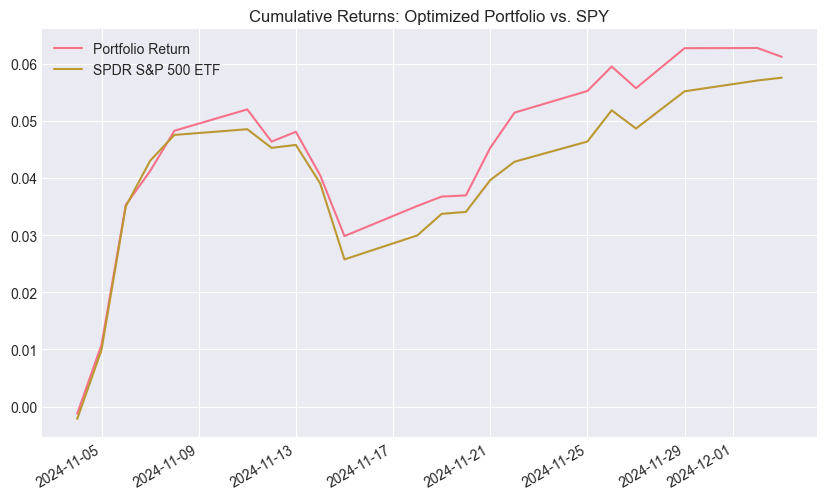

In [18]:
port_rets = pd.Series(dtype=float, name='Portfolio Return')
rets = fwd_rets.multiply(opt.optimal_weights).sum(axis=1).rename('Portfolio Return')

port_rets = pd.concat([port_rets, rets], axis=0)
ret_comp = port_rets.add(1).cumprod().sub(1).to_frame()\
    .join(etf_close_prices['SPDR S&P 500 ETF'].loc[DATE:port_rets.index[-1]].pct_change().add(1).cumprod().sub(1))
ret_comp.plot(figsize=(10,6), title='Cumulative Returns: Optimized Portfolio vs. SPY', grid=True)

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Risk (Volatility)', ylabel='Expected Return'>)

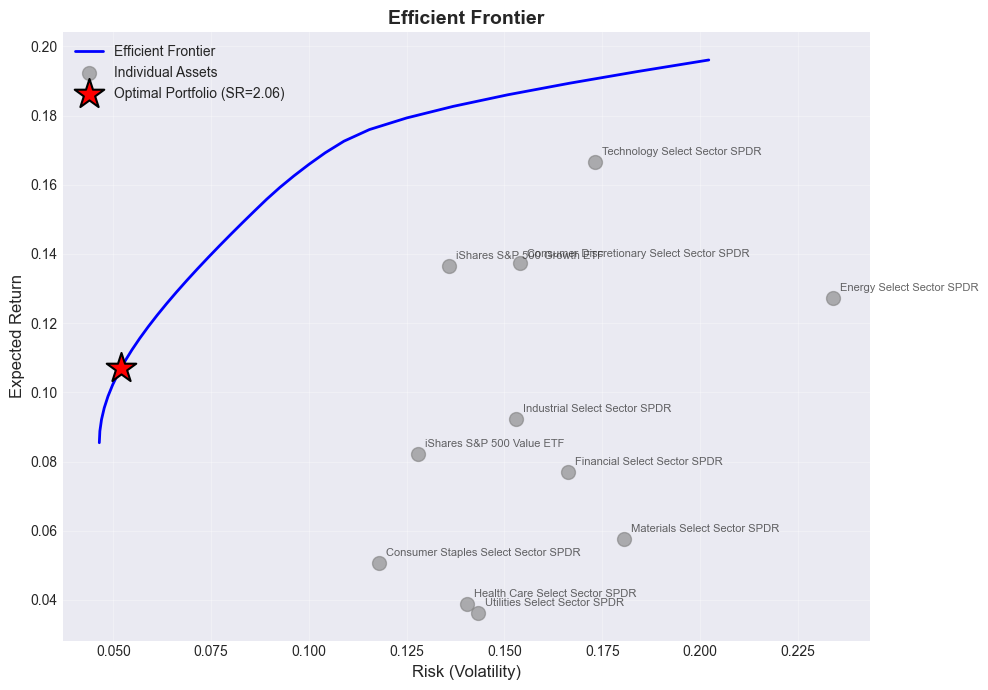

In [21]:
opt.plot_efficient_frontier(show_assets=True)